# Метод опорных векторов

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_circles, make_classification, make_regression, load_iris
from sklearn import metrics
from sklearn.svm import SVC, LinearSVC, SVR

def plot_decision_regions(X, y, model):
    plt.scatter(model.support_vectors_[:, 0],model.support_vectors_[:, 1], linewidth=7, facecolors='green')

    plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
    plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

    X0 = np.linspace(X[:, 0].min(),X[:, 0].max(), X.shape[0])
    X1 = np.linspace(X[:, 1].min(),X[:, 1].max(), X.shape[0])

    X0_grid, X1_grid = np.meshgrid(X0, X1)
    Z = model.decision_function(np.array([X0_grid.ravel(), X1_grid.ravel()]).T).reshape(X0_grid.shape)
    plt.contour(X0_grid, X1_grid, Z, colors='k', levels=[-1, 0, 1], linestyles=['--', '-', '--'])
    plt.contourf(X0_grid, X1_grid, Z, colors='k', levels=[-1, 0, 1], alpha=0.5)

    plt.title("Диаграмма рассеяния c линией разделения и зазором")
    plt.xlabel('X0')
    plt.ylabel('X1')
    plt.show()

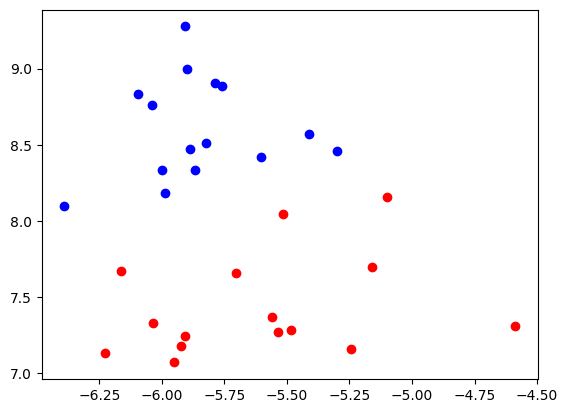

In [34]:
X, y = make_blobs(
    n_features=2,
    n_samples=30,
    centers=2,
    random_state=5,
    cluster_std=0.4
)

plt.scatter(X[:,0][y==0], X[:,1][y==0], c='red')
plt.scatter(X[:,0][y==1], X[:,1][y==1], c='blue')
plt.show()

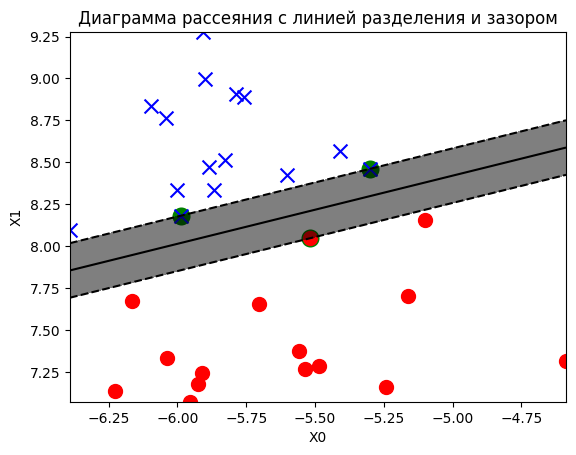

In [35]:
svm_linear = SVC(kernel='linear', C=100)
svm_linear.fit(X, y)

plot_decision_regions(X, y, svm_linear)

## Задания для самостоятельного выполнения

#### 1. В первом задании поэкспериментируйте с различными значениями аргумента C класса SVC. Сделайте вывод о том, как он влияет на модель классификации.


C = 0.1
Support vectors: [12 12]


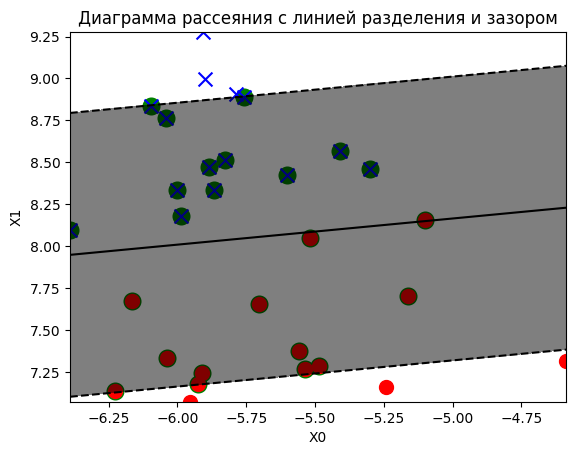


C = 1
Support vectors: [6 5]


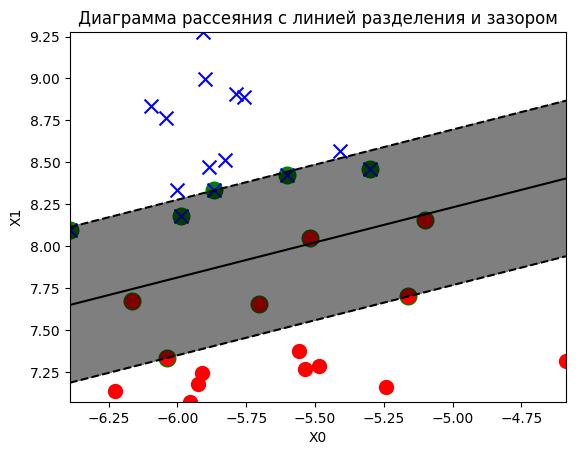


C = 10
Support vectors: [3 2]


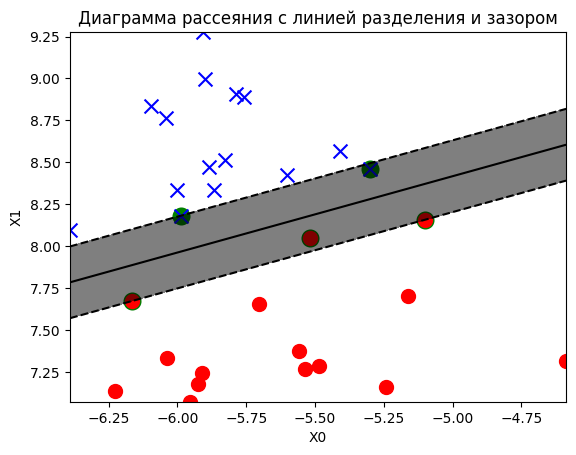


C = 100
Support vectors: [1 2]


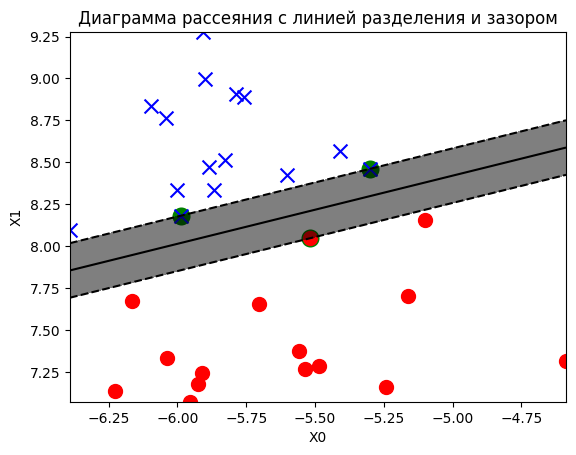

In [36]:
C_values = [0.1, 1, 10, 100]

for c in C_values:
    model = SVC(kernel='linear', C=c)
    model.fit(X, y)
    print(f"\nC = {c}")
    print(f"Support vectors: {model.n_support_}")
    
    plot_decision_regions(X, y, model)

# При увеличении C зазор становится более жёстким, количество опорных векторов уменьшается

#### 2. В первом задании подвигайте точку нового предсказания. Убедитесь, что с другой стороны границы предсказывается другой класс. Как изменяется предсказание, если точка ляжет внутрь полосы зазора?

In [37]:
points = [
    [-5, 7], # слева от границы (класс 0)
    [-5, 8.5], # внутри зазора
    [-5, 9] # справа от границы (класс 1)
]

for p in points:
    prediction = svm_linear.predict([p])
    decision = svm_linear.decision_function([p])
    print(f"\nPoint: {p}")
    print(f"Predicted class: {prediction[0]}")
    print(f"Decision value: {decision[0]:.3f}")
    
# decision value определяет класс, точки в зазоре имеют |decision value| < 1.


Point: [-5, 7]
Predicted class: 0
Decision value: -8.730

Point: [-5, 8.5]
Predicted class: 1
Decision value: 0.491

Point: [-5, 9]
Predicted class: 1
Decision value: 3.564


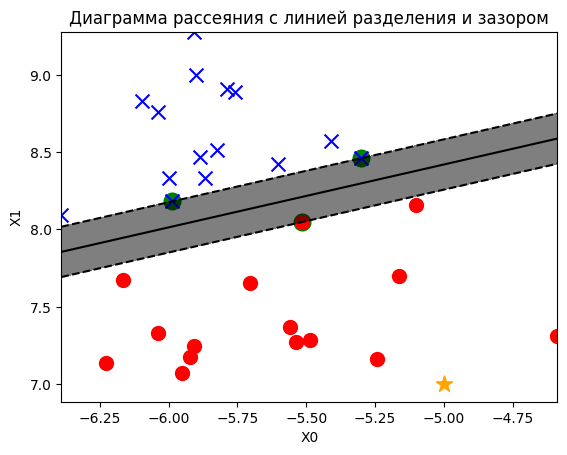

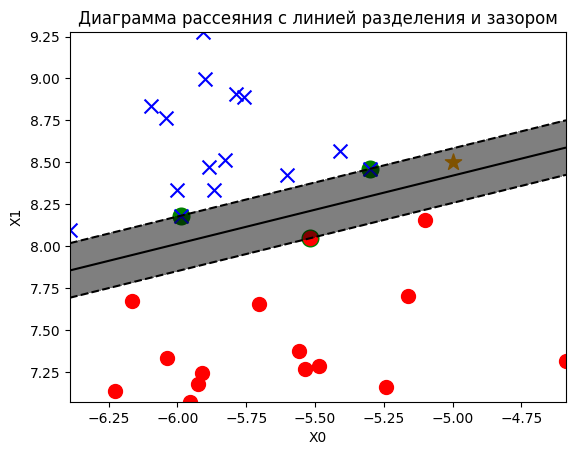

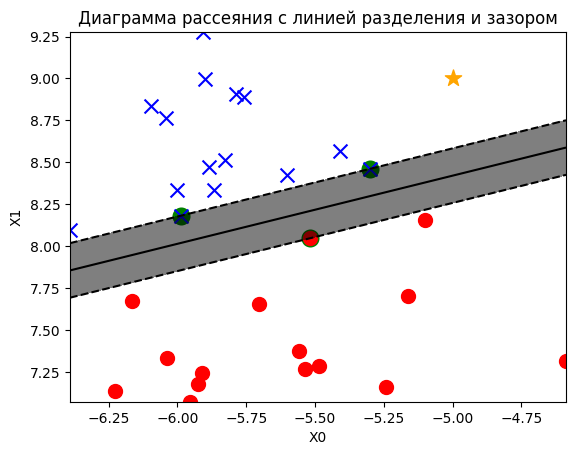

In [38]:
for p in points:
    plt.scatter(p[0], p[1], marker='*', s=150, color='orange')
    plot_decision_regions(X, y, svm_linear)

#### 3. Во втором задании повторите анализ с методом опорных векторов с другими видами ядер. Сравните вид границы принятия решения и показатели точности модели.

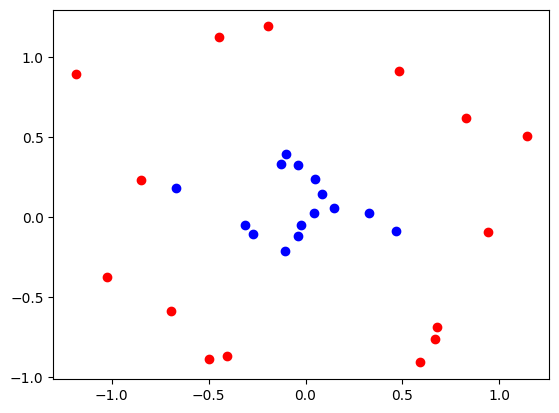

In [39]:
X, y = make_circles(n_samples=30, random_state=5, factor=0.1, noise=0.2)

plt.scatter(X[:,0][y==0], X[:,1][y==0], c='red')
plt.scatter(X[:,0][y==1], X[:,1][y==1], c='blue')
plt.show()


Kernel: linear
Accuracy: 0.700


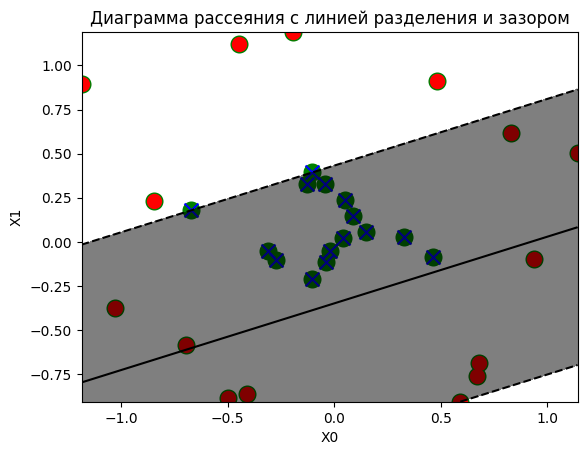


Kernel: rbf
Accuracy: 1.000


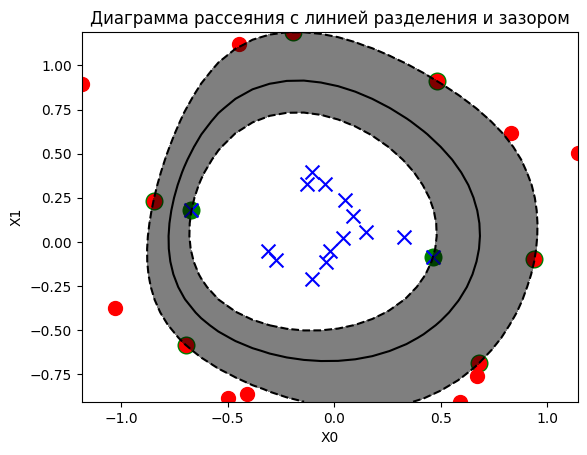


Kernel: poly
Accuracy: 0.700


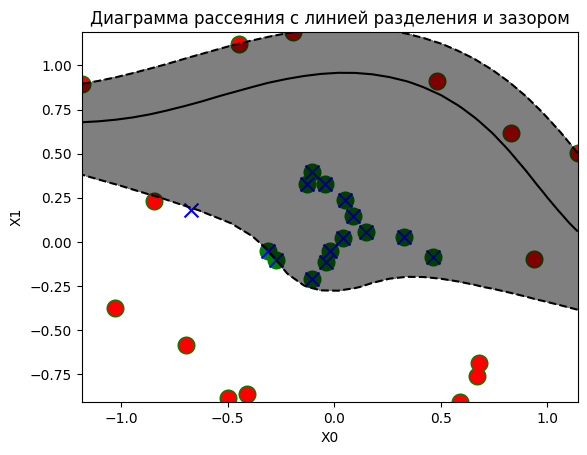

In [40]:
kernels = ['linear', 'rbf', 'poly']

for k in kernels:
    model = SVC(kernel=k, C=100)
    model.fit(X, y)
    y_pred = model.predict(X)
    print(f"\nKernel: {k}")
    print(f"Accuracy: {metrics.accuracy_score(y, y_pred):.3f}")

    plot_decision_regions(X, y, model)
    
# RBF ядро лучше всего справляется с нелинейно разделимыми данными

#### 4. В третьем задании поэкспериментируйте со значением аргумента C. Сделайтевывод о том, как он влияет на модель.


C = 0.1
accuracy: 0.767
support vectors: [15 15]


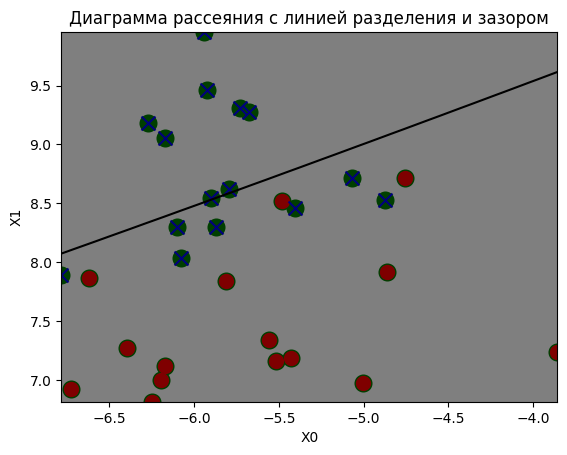


C = 1
accuracy: 0.800
support vectors: [10 11]


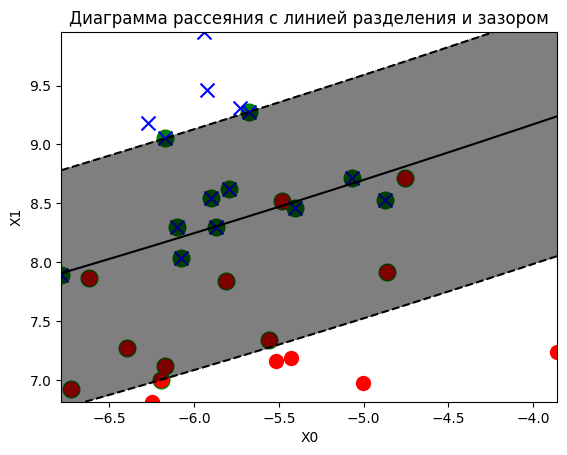


C = 10
accuracy: 0.900
support vectors: [6 6]


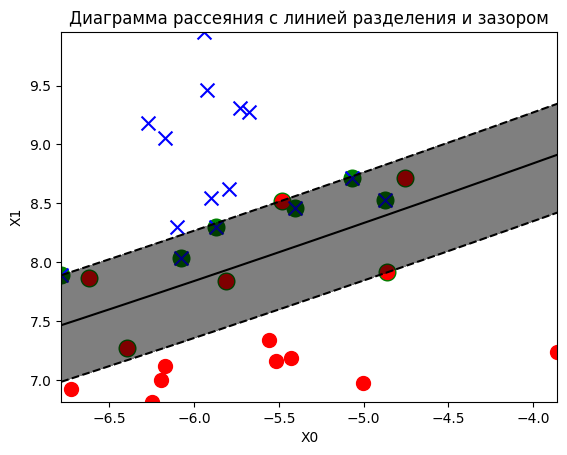

In [41]:
X, y = make_blobs(
    n_features=2,
    n_samples=30,
    centers=2,
    random_state=5,
    cluster_std=0.7
)

c_val = [0.1, 1, 10]

for c in c_val:
    model = SVC(kernel='poly', degree=4, C=c)
    model.fit(X, y)
    y_pred = model.predict(X)
    print(f"\nC = {c}")
    print(f"accuracy: {metrics.accuracy_score(y, y_pred):.3f}")
    print(f"support vectors: {model.n_support_}")

    plot_decision_regions(X, y, model)
    
# меньшее C дает мягкий зазор (больше опорных векторов), большее C дает жесткий зазор

#### 5. В третьем задании примените классификатор без ядра. Познакомьтесь и примените класс Linear_SVC.

In [42]:
from sklearn.svm import LinearSVC

model = LinearSVC(C=1)
model.fit(X, y)
y_pred = model.predict(X)

print(f"accuracy: {metrics.accuracy_score(y, y_pred)}")
# LinearSVC быстрее SVC с линейным ядром, но не предоставляет опорные вектора

accuracy: 0.8


#### 6. Сгенерируйте датасет для классификации из 1000 точек и 5 атрибутов. Попробуйте применить метод опорных векторов на нем. Найдите методом подбора наилучшее ядро и значение С.

In [43]:
X, y = make_classification(
    n_samples=1000,
    n_features=5,
    n_informative=3,
    n_classes=2,
    random_state=42
)

In [44]:
kernels = ['linear', 'rbf', 'poly']
C_values = [0.1, 1, 10]

best_score = 0
best_params = None

for k in kernels:
    for c in C_values:
        model = SVC(kernel=k, C=c)
        model.fit(X, y)
        score = model.score(X, y)
        print(f"Kernel: {k:6s}, C: {c:4.1f}, Score: {score:.4f}")
        
        if score > best_score:
            best_score = score
            best_params = (k, c)

print(f"\nbest parameters: kernel={best_params[0]}, C={best_params[1]}, Score={best_score:.4f}")

Kernel: linear, C:  0.1, Score: 0.9110
Kernel: linear, C:  1.0, Score: 0.9070
Kernel: linear, C: 10.0, Score: 0.9060
Kernel: rbf   , C:  0.1, Score: 0.9350
Kernel: rbf   , C:  1.0, Score: 0.9480
Kernel: rbf   , C: 10.0, Score: 0.9530
Kernel: poly  , C:  0.1, Score: 0.9050
Kernel: poly  , C:  1.0, Score: 0.9040
Kernel: poly  , C: 10.0, Score: 0.9170

best parameters: kernel=rbf, C=10, Score=0.9530


#### 7. Попробуйте данную модель с большим количеством точек. На каком количестве обучение начинает занимать существенное время?

In [45]:
import time

sizes = [1000, 2000, 5000, 10000]

print("Размер датасета, Время обучения (сек), Точность")

for s in sizes:
    X, y = make_classification(n_samples=s, n_features=5, random_state=42)
    start = time.time()
    model = SVC(kernel='rbf')
    model.fit(X, y)
    end = time.time()
    accuracy = model.score(X, y)
    
    print(f"{s}; {end-start:.3f}s; {accuracy:.3f}")
    
# Время обучения растёт квадратично с количеством точек

Размер датасета, Время обучения (сек), Точность
1000; 0.009s; 0.877
2000; 0.025s; 0.911
5000; 0.187s; 0.892
10000; 0.535s; 0.935


#### 8. Примените метод опорных векторов для задачи множественной классификации. Самостоятельно сгенерируйте визуализируемый датасет для этой задачи. Поробуйте изобразить границу принятия решений и зазор.

Accuracy: 1.000
Classes: [0 1 2]
Support vectors per class: [2 3 4]


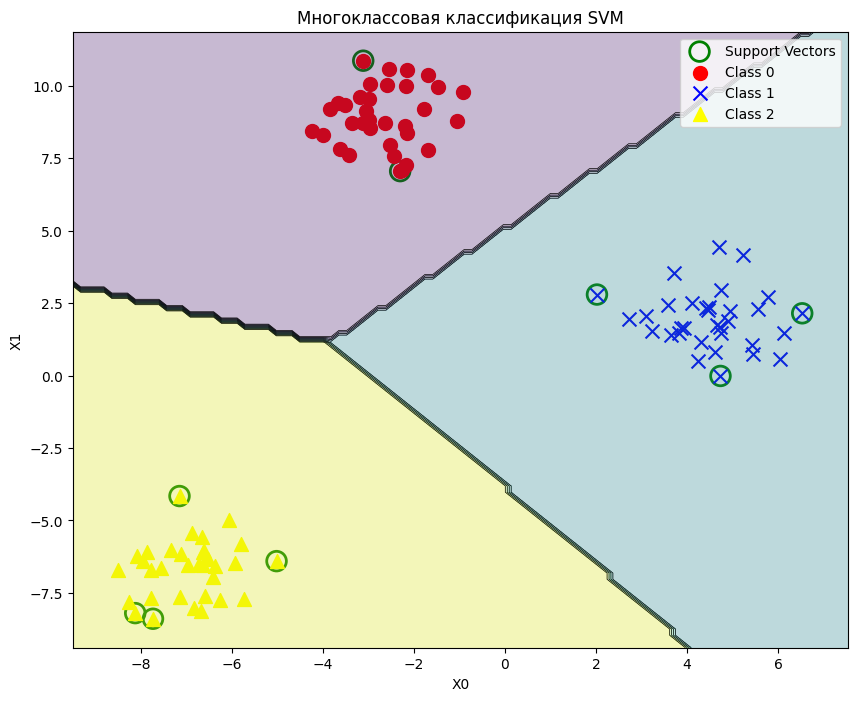

In [46]:
X, y = make_blobs(n_samples=100, centers=3, n_features=2, random_state=42)
model = SVC(kernel='rbf', C=10)
model.fit(X, y)

print(f"Accuracy: {model.score(X, y):.3f}")
print(f"Classes: {model.classes_}")
print(f"Support vectors per class: {model.n_support_}")

plt.figure(figsize=(10, 8))

plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], 
            s=200, linewidth=2, facecolors='none', edgecolors='green', label='Support Vectors')

colors = ['red', 'blue', 'yellow']
markers = ['o', 'x', '^']
for i, c in enumerate(model.classes_):
    plt.scatter(X[y==c, 0], X[y==c, 1], c=colors[i], marker=markers[i], s=100, label=f'Class {c}')

X0 = np.linspace(X[:, 0].min()-1, X[:, 0].max()+1, 100)
X1 = np.linspace(X[:, 1].min()-1, X[:, 1].max()+1, 100)
X0_grid, X1_grid = np.meshgrid(X0, X1)

Z = model.predict(np.c_[X0_grid.ravel(), X1_grid.ravel()])
Z = Z.reshape(X0_grid.shape)

plt.contourf(X0_grid, X1_grid, Z, alpha=0.3, cmap='viridis')
plt.contour(X0_grid, X1_grid, Z, colors='k', linewidths=0.5)

plt.title("Многоклассовая классификация SVM")
plt.xlabel('X0')
plt.ylabel('X1')
plt.legend()
plt.show()

# SVM использует стратегию 'one-vs-one' для многоклассовой классификации

#### 9. Выберите из библиотеки sklearn готовый датасет для классификации и попробуйте смоделировать его при помощи метода опорных векторов.

In [47]:
data = load_iris()
X = data.data
y = data.target

print("Dataset: Iris")
print(f"Samples: {len(X)}, Features: {X.shape[1]}, Classes: {len(np.unique(y))}")
print(f"Feature names: {data.feature_names}")
print(f"Target names: {data.target_names}")

print("kernels:")

kernels = ['linear', 'rbf', 'poly']
best_score = 0
best_kernel = None

for k in kernels:
    model = SVC(kernel=k, C=1)
    model.fit(X, y)
    y_pred = model.predict(X)
    score = metrics.accuracy_score(y, y_pred)
    print(f"\nKernel: {k}")
    print(f"Accuracy: {score:.4f}")
    print(f"Support vectors: {model.n_support_}")
    
    if score > best_score:
        best_score = score
        best_kernel = k

print(f"best kernel: {best_kernel}, accuracy {best_score:.4f}")

model = SVC(kernel=best_kernel, C=1)
model.fit(X, y)
y_pred = model.predict(X)

print("\nConfusion Matrix:")
print(metrics.confusion_matrix(y, y_pred))
print("\nClassification Report:")
print(metrics.classification_report(y, y_pred, target_names=data.target_names))

Dataset: Iris
Samples: 150, Features: 4, Classes: 3
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
kernels:

Kernel: linear
Accuracy: 0.9933
Support vectors: [ 3 12 12]

Kernel: rbf
Accuracy: 0.9733
Support vectors: [ 7 29 24]

Kernel: poly
Accuracy: 0.9733
Support vectors: [4 9 7]
best kernel: linear, accuracy 0.9933

Confusion Matrix:
[[50  0  0]
 [ 0 49  1]
 [ 0  0 50]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       1.00      0.98      0.99        50
   virginica       0.98      1.00      0.99        50

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150



#### 10. Повторите такой же анализ для задачи регрессии и соответствующего датасета.

Dataset: Diabetes
Samples: 442, Features: 10
Target: Disease progression after one year

Different kernels for SVR:

Kernel: linear; MSE: 5324.58; R^2: 0.0137
Kernel: rbf   ; MSE: 4525.81; R^2: 0.1616
Kernel: poly  ; MSE: 4046.78; R^2: 0.2504

Best kernel: poly with R^2 = 0.2504



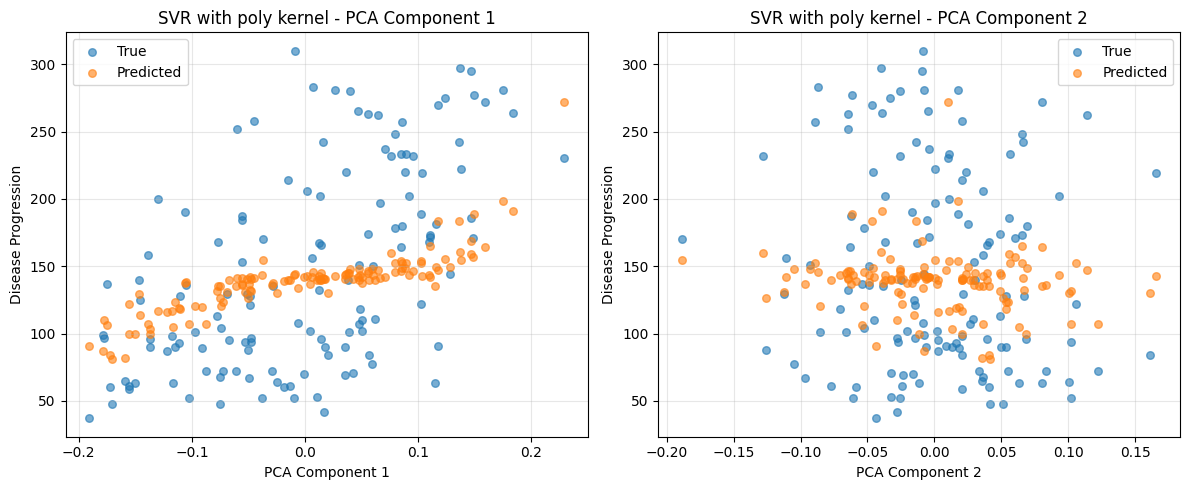

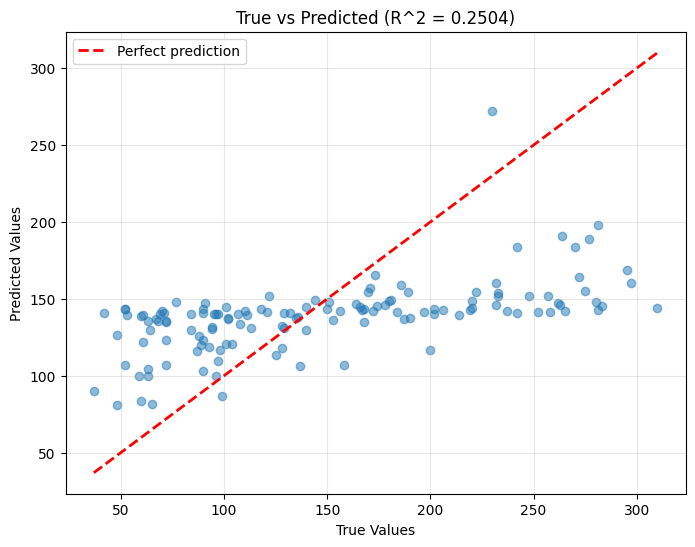

In [48]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn import datasets

data = datasets.load_diabetes()
X, y = data.data, data.target
print("Dataset: Diabetes")
print(f"Samples: {len(X)}, Features: {X.shape[1]}")
print(f"Target: Disease progression after one year\n")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

print("Different kernels for SVR:\n")
kernels = ['linear', 'rbf', 'poly']
best_r2 = -float('inf')
best_kernel = None
results = {}

for k in kernels:
    svr = SVR(kernel=k, C=1.0, epsilon=0.1, gamma='scale')
    svr.fit(X_train, y_train)
    y_pred = svr.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[k] = (svr, y_pred, mse, r2)
    print(f"Kernel: {k:6s}; MSE: {mse:7.2f}; R^2: {r2:.4f}")
    
    if r2 > best_r2:
        best_r2 = r2
        best_kernel = k

print(f"\nBest kernel: {best_kernel} with R^2 = {best_r2:.4f}\n")

pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)
best_svr, best_pred, best_mse, best_r2 = results[best_kernel]
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_test_pca[:, 0], y_test, label='True', alpha=0.6, s=30)
plt.scatter(X_test_pca[:, 0], best_pred, label='Predicted', alpha=0.6, s=30)
plt.xlabel('PCA Component 1')
plt.ylabel('Disease Progression')
plt.title(f'SVR with {best_kernel} kernel - PCA Component 1')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(X_test_pca[:, 1], y_test, label='True', alpha=0.6, s=30)
plt.scatter(X_test_pca[:, 1], best_pred, label='Predicted', alpha=0.6, s=30)
plt.xlabel('PCA Component 2')
plt.ylabel('Disease Progression')
plt.title(f'SVR with {best_kernel} kernel - PCA Component 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title(f'True vs Predicted (R^2 = {best_r2:.4f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()